[INFO] Using device: cpu
[INFO] Loading CLIP model...
[INFO] Loading dataset Codatta/MM-Food-100K...
[INFO] Pre-computing embeddings for 19288 labels...
[INFO] Dataset and Label Embeddings ready.



[INFO] Đang bắt đầu thực nghiệm trên 828 mẫu với Threshold 0.7...


100%|██████████| 828/828 [02:25<00:00,  5.67it/s]



[SUCCESS] Đã tạo báo cáo đầy đủ tại: Full_Evaluation_Report.md


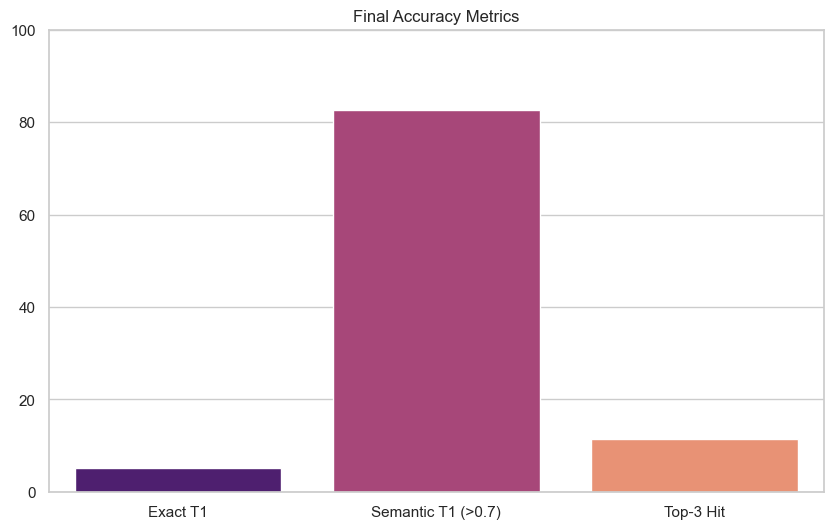

In [21]:
import os
# Ép chạy CPU để đảm bảo tính ổn định hệ thống
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import torch
import torch.nn.functional as F
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from FoodRecognizer import FoodRecognizer
from tqdm import tqdm
import warnings

# Cấu hình hệ thống
warnings.filterwarnings("ignore")
torch.set_num_threads(8) 
sns.set_theme(style="whitegrid")

def run_full_evaluation_report(metadata_path="local_test_metadata.csv", threshold=0.7):
    # 1. Khởi tạo mô hình và tri thức nhãn
    recognizer = FoodRecognizer()
    recognizer.prepare_dataset() 
    
    # Đọc toàn bộ dữ liệu kiểm thử (mặc định lấy 1000 mẫu nếu có đủ)
    df_test = pd.read_csv(metadata_path)
    test_size = len(df_test)
    
    exact_count = 0
    semantic_count = 0
    top3_count = 0
    latencies = []
    log_entries = [] # Lưu dữ liệu để xuất toàn bộ vào file .md

    print(f"\n[INFO] Đang bắt đầu thực nghiệm trên {test_size} mẫu với Threshold {threshold}...")
    
    for idx, row in tqdm(df_test.iterrows(), total=test_size):
        try:
            start_time = time.time()
            # Trích xuất Top-3 từ mô hình
            preds = recognizer.classify_image(top_k=3, custom_image=recognizer._load_image(row['local_path']))
            latencies.append(time.time() - start_time)
            
            gt = row['dish_name']
            t1 = preds[0]['label']
            t3_list = [p['label'] for p in preds]
            
            # Tính Cosine Similarity giữa Embedding của Top-1 và Ground Truth
            idx_p = recognizer.candidate_labels.index(t1)
            idx_g = recognizer.candidate_labels.index(gt)
            vec_p = recognizer.label_embeddings[idx_p].unsqueeze(0)
            vec_g = recognizer.label_embeddings[idx_g].unsqueeze(0)
            cos_sim = F.cosine_similarity(vec_p, vec_g).item()
            
            # Phân loại trạng thái dựa trên các tiêu chí
            is_exact = (t1 == gt)
            is_semantic = is_exact or (cos_sim >= threshold)
            is_top3 = any(p == gt for p in t3_list)

            # Xác định nhãn trạng thái cho log
            status = "MISS"
            if is_exact:
                exact_count += 1
                status = "EXACT"
            elif is_semantic:
                semantic_count += 1
                status = "SEMANTIC"
            
            if is_top3: top3_count += 1
            
            # Định dạng chuỗi Top-3 để đưa vào bảng
            t3_str = ", ".join([f"'{p}'" for p in t3_list])
            
            # Thêm vào danh sách log (Toàn bộ 800-1000 mẫu)
            log_entries.append(f"| {idx+1} | {gt} | {t1} | {t3_str} | {cos_sim:.3f} | {status} |")

        except Exception:
            continue

    # 2. Tổng kết các tỷ lệ chính xác
    valid_n = len(latencies)
    final_exact = (exact_count / valid_n) * 100
    final_semantic = (semantic_count / valid_n) * 100 # Bao gồm cả Exact và Semantic Match
    final_top3 = (top3_count / valid_n) * 100
    avg_lat = sum(latencies) / valid_n

    # 3. Xây dựng nội dung file Markdown
    md_header = f"""# BÁO CÁO THỰC NGHIỆM CHI TIẾT (NGƯỠNG 0.7)

## 1. Thông số Hệ thống
- **Mô hình:** CLIP ViT-B/32 (Zero-shot)
- **Số lượng mẫu thử (N):** {valid_n}
- **Ngưỡng tương đồng (Threshold):** {threshold}
- **Thiết bị xử lý:** CPU Intel Core i7-11800H

## 2. Tỷ lệ Chính xác Tổng hợp
| Chỉ số Accuracy | Tỷ lệ (%) | Ý nghĩa |
| :--- | :--- | :--- |
| **Exact Top-1** | {final_exact:.2f}% | Khớp chính xác hoàn toàn nhãn gốc |
| **Semantic Top-1** | {final_semantic:.2f}% | Khớp ngữ nghĩa (Similarity >= {threshold}) |
| **Top-3 Hit Rate** | {final_top3:.2f}% | Nhãn gốc nằm trong 3 dự đoán đầu |
| **Latency Avg** | {avg_lat:.3f}s | Thời gian xử lý trung bình/ảnh |

## 3. Nhật ký kiểm thử chi tiết (Toàn bộ mẫu)
| STT | Ground Truth | Top-1 (1K) | Top-3 Predictions (3K) | CosSim | Status |
| :--- | :--- | :--- | :--- | :--- | :--- |
"""
    # Gộp toàn bộ log entries vào nội dung file
    full_md = md_header + "\n".join(log_entries)

    # Xuất file .md
    with open("Full_Evaluation_Report.md", "w", encoding="utf-8") as f:
        f.write(full_md)
    
    print(f"\n[SUCCESS] Đã tạo báo cáo đầy đủ tại: Full_Evaluation_Report.md")

    # 4. Vẽ biểu đồ so sánh nhanh
    plt.figure(figsize=(10, 6))
    sns.barplot(x=['Exact T1', f'Semantic T1 (>{threshold})', 'Top-3 Hit'], 
                y=[final_exact, final_semantic, final_top3], palette="magma")
    plt.ylim(0, 100)
    plt.title("Final Accuracy Metrics")
    plt.savefig("final_accuracy_chart.png")
    plt.show()

if __name__ == "__main__":
    run_full_evaluation_report()